<a href="https://colab.research.google.com/github/auroradefence/auroradefence/blob/main/Self_learningMachine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
from sklearn.linear_model import LinearRegression,Ridge,RidgeClassifier,LogisticRegression,ElasticNet,Lasso
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,KFold,StratifiedKFold,cross_val_score,learning_curve
from sklearn.metrics import accuracy_score,f1_score,recall_score,confusion_matrix,roc_auc_score,roc_curve,precision_score,\
mean_squared_error, mean_absolute_error, r2_score,ConfusionMatrixDisplay
from sklearn.svm import SVC,SVR
from sklearn.datasets import load_iris

In [32]:

dataset = sns.get_dataset_names()

In [33]:
dataset

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [34]:
dataset = sns.load_dataset('penguins')

In [35]:
dataset

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [36]:
dataset = dataset.dropna()

In [37]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


In [38]:
x = dataset.drop(columns=['species'])
x = pd.get_dummies(x, drop_first=True)
y = dataset['species']

In [39]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     333 non-null    float64
 1   bill_depth_mm      333 non-null    float64
 2   flipper_length_mm  333 non-null    float64
 3   body_mass_g        333 non-null    float64
 4   island_Dream       333 non-null    bool   
 5   island_Torgersen   333 non-null    bool   
 6   sex_Male           333 non-null    bool   
dtypes: bool(3), float64(4)
memory usage: 14.0 KB


In [40]:
y.info()

<class 'pandas.core.series.Series'>
Index: 333 entries, 0 to 343
Series name: species
Non-Null Count  Dtype 
--------------  ----- 
333 non-null    object
dtypes: object(1)
memory usage: 5.2+ KB


In [41]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.4,random_state=42,shuffle=True)

In [42]:
model_training = RandomForestClassifier()

In [43]:
model_training

RandomForestClassifier()

In [44]:
randomforestmodel = model_training.fit(x_train, y_train)

In [45]:
predict_model = randomforestmodel.predict(x_test)

In [46]:
predict_model

array(['Adelie', 'Gentoo', 'Adelie', 'Chinstrap', 'Adelie', 'Gentoo',
       'Gentoo', 'Chinstrap', 'Chinstrap', 'Chinstrap', 'Adelie',
       'Adelie', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie', 'Adelie',
       'Chinstrap', 'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Gentoo',
       'Chinstrap', 'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Chinstrap',
       'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie', 'Gentoo',
       'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Chinstrap', 'Chinstrap', 'Adelie', 'Adelie', 'Gentoo',
       'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Gentoo', 'Gentoo',
       'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Chinstrap',
       'Chinstrap', 'Gentoo', 'Gentoo', 'Gentoo', 'Adelie', 'Adelie',
       'Gentoo', 'Adelie', 'Gentoo', 'Adelie', 'Gentoo', 'Adelie',
       'Adelie', 'Gentoo', 'Gentoo', 'Gentoo', 'Chinstrap', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Gentoo', 'Ge

In [47]:
y_test

,species
30,Adelie
317,Gentoo
79,Adelie
201,Chinstrap
63,Adelie
...,...
214,Chinstrap
102,Adelie
103,Adelie
204,Chinstrap


Model Accuracy: 0.99


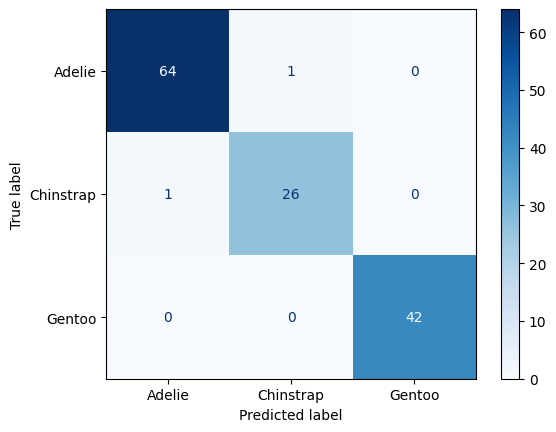

In [51]:
# from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Calculate Accuracy
accuracy = accuracy_score(y_test,predict_model )
print(f"Model Accuracy: {accuracy:.2f}")

# Generate and Display Confusion Matrix
cm = confusion_matrix(y_test, predict_model)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=randomforestmodel.classes_)
disp.plot(cmap='Blues')

In [52]:
new_dataset = sns.get_dataset_names()

In [53]:
new_dataset

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [57]:
new_dataset = sns.load_dataset('car_crashes')

In [58]:
new_dataset

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA
5,13.6,5.032,3.808,10.744,12.920,835.50,139.91,CO
6,10.8,4.968,3.888,9.396,8.856,1068.73,167.02,CT
7,16.2,6.156,4.860,14.094,16.038,1137.87,151.48,DE
8,5.9,2.006,1.593,5.900,5.900,1273.89,136.05,DC
9,17.9,3.759,5.191,16.468,16.826,1160.13,144.18,FL


In [63]:
x = new_dataset.drop(columns =['abbrev'])
y = new_dataset['abbrev']

In [64]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   total           51 non-null     float64
 1   speeding        51 non-null     float64
 2   alcohol         51 non-null     float64
 3   not_distracted  51 non-null     float64
 4   no_previous     51 non-null     float64
 5   ins_premium     51 non-null     float64
 6   ins_losses      51 non-null     float64
dtypes: float64(7)
memory usage: 2.9 KB


In [65]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 51 entries, 0 to 50
Series name: abbrev
Non-Null Count  Dtype 
--------------  ----- 
51 non-null     object
dtypes: object(1)
memory usage: 540.0+ bytes


In [84]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.4,random_state=42,shuffle=True)

In [85]:
model_training = DecisionTreeClassifier()

In [86]:
model_training

DecisionTreeClassifier()

In [87]:
fit_model = model_training.fit(x_train,y_train)

In [88]:
model_predict = fit_model.predict(x_test)

In [89]:
model_predict

array(['PA', 'PA', 'NH', 'SD', 'MN', 'MI', 'TN', 'NH', 'TN', 'MA', 'MD',
       'MN', 'MN', 'RI', 'OR', 'NH', 'LA', 'IN', 'SD', 'PA', 'SD'],
      dtype=object)

In [90]:
y_test

,abbrev
43,TX
40,SC
46,VA
12,ID
24,MS
31,NM
17,KY
32,NY
3,AR
30,NJ


Model Accuracy: 0.00


ValueError: The number of FixedLocator locations (33), usually from a call to set_ticks, does not match the number of labels (30).

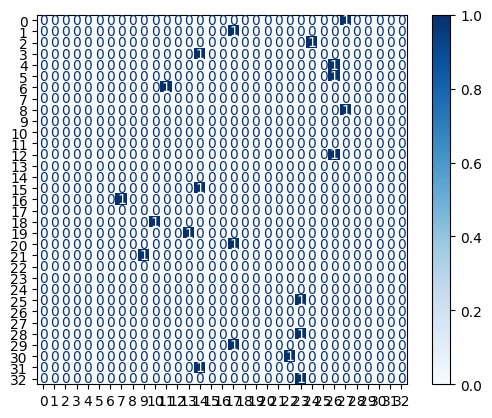

In [93]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Accuracy
accuracy = accuracy_score(y_test, model_predict)
print(f"Model Accuracy: {accuracy:.2f}")

# Confusion matrix
cm = confusion_matrix(y_test, model_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=fit_model.classes_)
disp.plot(cmap='Blues')